In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday


In [6]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="InvoiceDate",
            freq="ME"
        )
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales = monthly_sales.iloc[:-1].copy()

monthly_sales["Month_Index"] = range(len(monthly_sales))

monthly_sales.head()

,InvoiceDate,Revenue,Month_Index
0,2009-12-31,683504.010,0
1,2010-01-31,555802.672,1
2,2010-02-28,504558.956,2
3,2010-03-31,696978.471,3
4,2010-04-30,591982.002,4


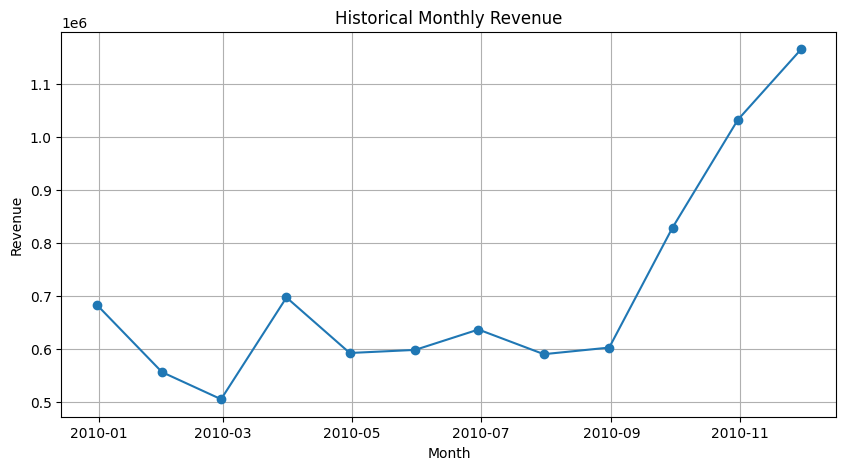

In [7]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Historical Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [8]:
# creating month index
monthly_sales["Month_Index"] = range(len(monthly_sales))

monthly_sales.head()

,InvoiceDate,Revenue,Month_Index
0,2009-12-31,683504.010,0
1,2010-01-31,555802.672,1
2,2010-02-28,504558.956,2
3,2010-03-31,696978.471,3
4,2010-04-30,591982.002,4


In [9]:
# training forecast model
from sklearn.linear_model import LinearRegression

X = monthly_sales[["Month_Index"]]
y = monthly_sales["Revenue"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[39991.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Month_Index']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.873e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [10]:
# generating forecast
future_months = pd.DataFrame({
    "Month_Index": [12, 13, 14]
})

forecast = model.predict(future_months)

forecast

array([ 967241.66081818, 1007232.97563636, 1047224.29045455])

In [11]:
# creating forecast table
forecast_df = pd.DataFrame({
    "Forecast_Month": [
        "Month+1",
        "Month+2",
        "Month+3"
    ],
    "Predicted_Revenue": forecast
})

forecast_df

,Forecast_Month,Predicted_Revenue
0,Month+1,9.672417e+05
1,Month+2,1.007233e+06
2,Month+3,1.047224e+06


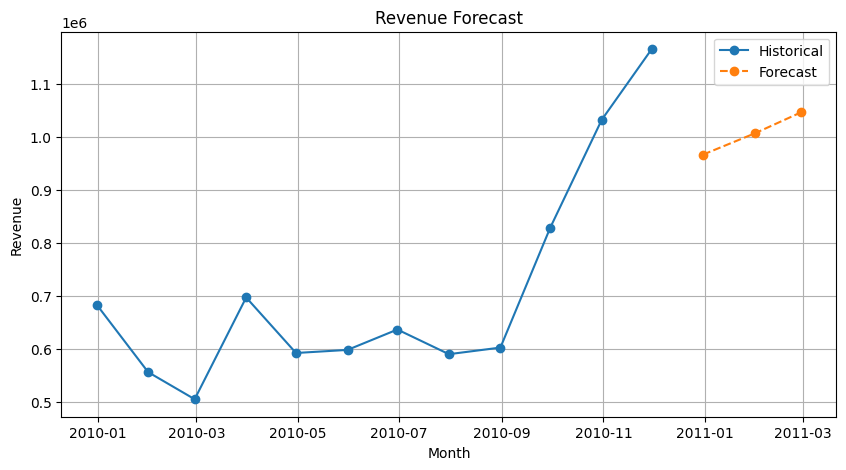

In [12]:
future_dates = pd.date_range(
    start=monthly_sales["InvoiceDate"].max(),
    periods=4,
    freq="ME"
)[1:]

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Revenue"],
    marker="o",
    label="Historical"
)

plt.plot(
    future_dates,
    forecast,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()
plt.grid(True)

plt.show()

# Demand Forecasting Insights

1. Historical sales show a positive growth trend over time.
2. Revenue increases significantly during the final quarter of the year.
3. The forecasting model predicts future sales based on historical trends.
4. Forecasted revenue can support inventory planning and resource allocation.
5. Demand forecasting helps reduce stock shortages and overstock situations.

In [13]:
forecast_df.to_csv(
    "../data/sales_forecast.csv",
    index=False
)